In [2]:
import pandas as pd
# My teammate Matias preprocessed the dataset, removed invalid rows of data. 
df = pd.read_csv('crypto_cleaned.csv')
print(f' Row and Column # in the dataset: {df.shape}')
print(f'The column names: {df.columns}')


 Row and Column # in the dataset: (824600, 14)
The column names: Index(['slug', 'symbol', 'name', 'date', 'ranknow', 'open', 'high', 'low',
       'close', 'volume', 'market', 'close_ratio', 'spread',
       'volume_missing_flag'],
      dtype='object')


In [3]:
df['date'].min(), df['date'].max(), df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 824600 entries, 0 to 824599
Data columns (total 14 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   slug                 824600 non-null  object 
 1   symbol               824600 non-null  object 
 2   name                 824600 non-null  object 
 3   date                 824600 non-null  object 
 4   ranknow              824600 non-null  int64  
 5   open                 824600 non-null  float64
 6   high                 824600 non-null  float64
 7   low                  824600 non-null  float64
 8   close                824600 non-null  float64
 9   volume               824600 non-null  float64
 10  market               824600 non-null  float64
 11  close_ratio          824600 non-null  float64
 12  spread               824600 non-null  float64
 13  volume_missing_flag  824600 non-null  bool   
dtypes: bool(1), float64(8), int64(1), object(4)
memory usage: 82.6+ MB


('2013-04-28', '2018-11-30', None)

In [4]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam


# Convert date column to datetime and sort by date
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
# Create more features based on existing ones. Suggested by my teammate Soumya.
df['spread'] = df['high'] - df['low']
df['return'] = (df['close'] - df['open']) / df['open']

df = df.dropna()
df.head()

2025-07-27 13:46:58.674707: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


,slug,symbol,name,date,ranknow,open,high,low,close,volume,market,close_ratio,spread,volume_missing_flag,return
0,bitcoin,BTC,Bitcoin,2013-04-28,1,135.300000,135.980000,132.100000,134.210000,0.0,1.488567e+09,0.5438,3.880000,True,-0.008056
307068,novacoin,NVC,Novacoin,2013-04-28,700,4.220000,4.250000,4.040000,4.250000,0.0,1.162268e+06,1.0000,0.210000,True,0.007109
185144,namecoin,NMC,Namecoin,2013-04-28,371,1.100000,1.120000,1.080000,1.110000,0.0,5.995983e+06,0.7500,0.040000,True,0.009091
386338,terracoin,TRC,Terracoin,2013-04-28,895,0.650793,0.654064,0.634409,0.646892,0.0,1.503099e+06,0.6351,0.019655,True,-0.005994
7776,litecoin,LTC,Litecoin,2013-04-28,7,4.300000,4.400000,4.180000,4.350000,0.0,7.463694e+07,0.7727,0.220000,True,0.011628


In [5]:
# Target: the close price on the next day
df.sort_values(by=['symbol','date'],inplace=True)
df['target'] = df.groupby('symbol')['close'].shift(-1)
df[df['symbol']=='BTC'].head()

            

,slug,symbol,name,date,ranknow,open,high,low,close,volume,market,close_ratio,spread,volume_missing_flag,return,target
0,bitcoin,BTC,Bitcoin,2013-04-28,1,135.30,135.98,132.10,134.21,0.0,1.488567e+09,0.5438,3.88,True,-0.008056,144.54
1,bitcoin,BTC,Bitcoin,2013-04-29,1,134.44,147.49,134.00,144.54,0.0,1.603769e+09,0.7813,13.49,True,0.075126,139.00
2,bitcoin,BTC,Bitcoin,2013-04-30,1,144.00,146.93,134.05,139.00,0.0,1.542813e+09,0.3843,12.88,True,-0.034722,116.99
3,bitcoin,BTC,Bitcoin,2013-05-01,1,139.00,139.89,107.72,116.99,0.0,1.298955e+09,0.2882,32.17,True,-0.158345,105.21
4,bitcoin,BTC,Bitcoin,2013-05-02,1,116.38,125.60,92.28,105.21,0.0,1.168517e+09,0.3881,33.32,True,-0.095979,97.75


In [ ]:
df[['date','symbol','close','target']].head(15)

In [8]:
df['ma_3'] = df.groupby('symbol')['close'].rolling(window=3, min_periods=1).mean().reset_index(level=0, drop=True)
df['ma_7'] = df.groupby('symbol')['close'].rolling(window=7, min_periods=1).mean().reset_index(level=0, drop=True)
df['ma_14'] = df.groupby('symbol')['close'].rolling(window=14, min_periods=1).mean().reset_index(level=0, drop=True)
df['volatility_7'] = df.groupby('symbol')['close'].rolling(window=7, min_periods=1).std().reset_index(level=0, drop=True)
df.head()

,slug,symbol,name,date,ranknow,open,high,low,close,volume,market,close_ratio,spread,volume_missing_flag,return,target,ma_3,ma_7,ma_14,volatility_7
753254,money,$$$,Money,2015-12-10,1634,0.000084,0.000084,0.000021,0.000050,86.0,2289.0,0.4603,0.000063,False,-0.404762,0.000027,0.000050,0.000050,0.000050,NaN
753255,money,$$$,Money,2015-12-11,1634,0.000050,0.000050,0.000022,0.000027,1.0,1244.0,0.1786,0.000028,False,-0.460000,0.000043,0.000039,0.000039,0.000039,0.000016
753256,money,$$$,Money,2015-12-12,1634,0.000027,0.000044,0.000021,0.000043,0.0,1996.0,0.9565,0.000023,True,0.592593,0.000022,0.000040,0.000040,0.000040,0.000012
753257,money,$$$,Money,2015-12-13,1634,0.000043,0.000044,0.000022,0.000022,2.0,995.0,0.0000,0.000022,False,-0.488372,0.000022,0.000031,0.000036,0.000036,0.000013
753258,money,$$$,Money,2015-12-14,1634,0.000022,0.000022,0.000022,0.000022,3.0,1019.0,0.0000,0.000000,False,0.000000,0.000023,0.000029,0.000033,0.000033,0.000013


In [33]:
# Encode symbols for the coins
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
symbol_encoder = LabelEncoder()

# Encode the 'Symbol' column
df['symbol_encoded'] = symbol_encoder.fit_transform(df['symbol'])

# Print the DataFrame with encoded column
print(df[['symbol','symbol_encoded']].head)

# the mapping of symbols to numeric values
print("Symbol to Numeric Mapping:", dict(zip(symbol_encoder.classes_, symbol_encoder.transform(symbol_encoder.classes_))))


<bound method NDFrame.head of        symbol  symbol_encoded
612276    FRC             603
6         BTC             235
89422     PPC            1162
7782      LTC             877
684101    MNC             941
...       ...             ...
704493    ONX            1074
23224     ONT            1073
493229   OPEN            1079
823724     42               9
824163  BTWTY             255

[824560 rows x 2 columns]>
Symbol to Numeric Mapping: {'$$$': np.int64(0), '$PAC': np.int64(1), '0XBTC': np.int64(2), '1337': np.int64(3), '1ST': np.int64(4), '1WO': np.int64(5), '2GIVE': np.int64(6), '2GO': np.int64(7), '300': np.int64(8), '42': np.int64(9), '611': np.int64(10), '808': np.int64(11), '8BIT': np.int64(12), 'AAA': np.int64(13), 'AAC': np.int64(14), 'ABL': np.int64(15), 'ABS': np.int64(16), 'ABT': np.int64(17), 'ABX': np.int64(18), 'ABY': np.int64(19), 'ABYSS': np.int64(20), 'AC': np.int64(21), 'AC3': np.int64(22), 'ACAT': np.int64(23), 'ACC': np.int64(24), 'ACE': np.int64(25), 'ACED': np

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 824560 entries, 612276 to 824163
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   slug                 824560 non-null  object        
 1   symbol               824560 non-null  object        
 2   name                 824560 non-null  object        
 3   date                 824560 non-null  datetime64[ns]
 4   ranknow              824560 non-null  int64         
 5   open                 824560 non-null  float64       
 6   high                 824560 non-null  float64       
 7   low                  824560 non-null  float64       
 8   close                824560 non-null  float64       
 9   volume               824560 non-null  float64       
 10  market               824560 non-null  float64       
 11  close_ratio          824560 non-null  float64       
 12  spread               824560 non-null  float64       
 13  volume_missing

In [43]:
symbol_counts = df.groupby('symbol').size()

In [56]:
# Keep only symbols with row count >= 50 to ensure enough training data for the model.
symbols_2_predict = symbol_counts[symbol_counts >= 50].index
len(symbols_2_predict)

1565

In [61]:
X = df.drop(columns=['date', 'slug','volume_missing_flag','symbol','name','target'])[df['symbol']=='$$$']

In [85]:
# Create sequences for GRU
def create_sequences(X, y, time_steps=10):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

In [108]:
# 10 coins with the larget market value on the specified date. 
# 2018-11-30 is the larget date in the dataset but there are only 2 rows so the previous day is picked.
# More details aobut these coins will be collected in the model training.
symbols_largest_market = df[df['date']=='2018-11-29 00:00:00'].nlargest(10,'market')['symbol']
symbols_largest_market

2041      BTC
3985      XRP
5196      ETH
7260      BCH
6774      XLM
7775      EOS
9817      LTC
11186    USDT
11190     BSV
11614     ADA
Name: symbol, dtype: object

In [ ]:
import pickle

In [ ]:
# Normalize/scale features
scaler = MinMaxScaler()

time_steps = 7  # Number of time steps in each sequence

evaluation_results = []
prediction_results = {}

for symbol in symbols_2_predict:
    # Extract features and target
    X = df.drop(columns=['date', 'slug','volume_missing_flag','symbol','name','target'])[df['symbol']==symbol]
    y = df[df['symbol']==symbol]['target']
    # fill the null values with the previous target value
    y.ffill(inplace=True)
    y = y.values
    
    # normalize features
    X_scaled = scaler.fit_transform(X)
    X_seq, y_seq = create_sequences(X_scaled, y, time_steps)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, shuffle=False)

    model = Sequential([
        GRU(units=64, return_sequences=True, input_shape=(time_steps, X_train.shape[2])),
        # Dropout(0.2),
        GRU(units=32),
        # Dropout(0.2),
        Dense(units=16, activation='relu'),
        Dense(units=1,activation='linear')  # Output layer for regression
    ])

    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

    history = model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=16,
        validation_split=0.2,
        verbose=1
    )
    print(type(history))

    test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)

    predictions = model.predict(X_test)

    evaluation_results.append([symbol,test_loss,test_mae])

    if symbol in symbols_largest_market.values:
        prediction_results[symbol] = predictions.flatten()

        pickle_file_name = 'gru_model_'+symbol+'.pkl'
        with open(pickle_file_name, 'wb') as file:
            pickle.dump(model, file)

    

Epoch 1/20


/var/folders/xd/827g3ndd0kg_81hlxd5mbp2m0000gn/T/ipykernel_34242/115997661.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y.ffill(inplace=True)
/opt/miniconda3/envs/dsi_xz/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 6.6098e-05 - mae: 0.0058 - val_loss: 0.0010 - val_mae: 0.0157
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3.9101e-06 - mae: 0.0016 - val_loss: 0.0011 - val_mae: 0.0162
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 7.3960e-07 - mae: 6.8850e-04 - val_loss: 0.0010 - val_mae: 0.0158
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6.7553e-07 - mae: 6.3350e-04 - val_loss: 0.0011 - val_mae: 0.0184
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.4140e-06 - mae: 0.0013 - val_loss: 9.4847e-04 - val_mae: 0.0164
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 8.0154e-07 - mae: 7.0817e-04 - val_loss: 9.3013e-04 - val_mae: 0.0153
Epoch 7/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.4250e-06 - mae: 0.0013 - val_loss: 9.5716e-04 - val_mae: 0.0149
Epoch 8/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.1743e-06 - mae: 8.8132e-04 - val_loss: 9.7985e-04 - val_mae: 0.0151
Epoch 9/20


/var/folders/xd/827g3ndd0kg_81hlxd5mbp2m0000gn/T/ipykernel_34242/115997661.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y.ffill(inplace=True)
/opt/miniconda3/envs/dsi_xz/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.0106 - mae: 0.0735 - val_loss: 0.0012 - val_mae: 0.0344
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 7.4703e-04 - mae: 0.0228 - val_loss: 1.7936e-04 - val_mae: 0.0105
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2.9222e-04 - mae: 0.0136 - val_loss: 3.3664e-04 - val_mae: 0.0178
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.3263e-04 - mae: 0.0089 - val_loss: 5.7851e-05 - val_mae: 0.0059
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 7.7590e-05 - mae: 0.0068 - val_loss: 2.8032e-05 - val_mae: 0.0041
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 4.5992e-05 - mae: 0.0050 - val_loss: 1.3187e-05 - val_mae: 0.0027
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 4.3687e-05 - mae: 0.0049 - val_loss: 7.0696e-06 - val_mae: 0.0021
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 3.4453e-05 - mae: 0.0045 - val_loss: 8.1420e-06 - val_mae: 0.0021
Epoch 9/20
13/13 ━━

...

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 53s 849ms/step - loss: 3.0943e-04 - mae: 0.0137 - val_loss: 1.5361e-05 - val_mae: 0.0029
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 174ms/step - loss: 6.4773e-05 - mae: 0.0055 - val_loss: 1.0828e-05 - val_mae: 0.0029
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 175ms/step - loss: 4.1672e-05 - mae: 0.0038 - val_loss: 4.6258e-06 - val_mae: 0.0017
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 182ms/step - loss: 3.1699e-05 - mae: 0.0036 - val_loss: 4.0193e-06 - val_mae: 0.0016
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 177ms/step - loss: 1.6327e-05 - mae: 0.0028 - val_loss: 9.4789e-06 - val_mae: 0.0029
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 174ms/step - loss: 3.0494e-05 - mae: 0.0033 - val_loss: 4.4207e-06 - val_mae: 0.0018
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 171ms/step - loss: 9.6646e-05 - mae: 0.0057 - val_loss: 4.0295e-05 - val_mae: 0.0061
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 177ms/step - loss: 3.0881e-05 - mae: 0.0038 - val_loss: 9.8234e-06 - val_mae

/var/folders/xd/827g3ndd0kg_81hlxd5mbp2m0000gn/T/ipykernel_34242/115997661.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y.ffill(inplace=True)
/opt/miniconda3/envs/dsi_xz/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 23s 130ms/step - loss: 0.0040 - mae: 0.0509 - val_loss: 4.6027e-04 - val_mae: 0.0186
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 6.6835e-04 - mae: 0.0186 - val_loss: 1.1374e-04 - val_mae: 0.0087
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 2.1616e-04 - mae: 0.0122 - val_loss: 1.8762e-04 - val_mae: 0.0120
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.1787e-04 - mae: 0.0089 - val_loss: 6.0304e-05 - val_mae: 0.0069
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 6.5394e-05 - mae: 0.0065 - val_loss: 6.2919e-05 - val_mae: 0.0063
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 6.5571e-05 - mae: 0.0067 - val_loss: 2.6026e-05 - val_mae: 0.0041
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 5.5038e-05 - mae: 0.0060 - val_loss: 2.1120e-05 - val_mae: 0.0036
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 3.5856e-05 - mae: 0.0047 - val_loss: 6.9725e-05 - val_mae: 0.0070
Epoch 9/20
8/8 ━━━

/var/folders/xd/827g3ndd0kg_81hlxd5mbp2m0000gn/T/ipykernel_34242/115997661.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y.ffill(inplace=True)
/opt/miniconda3/envs/dsi_xz/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


KeyboardInterrupt: 

In [124]:

columns = ['symbol','test_loss','test_mae']
df_test_results = pd.DataFrame(evaluation_results,columns=columns)
df_test_results.head()

,symbol,test_loss,test_mae
0,$$$,1.210385e-05,0.001534
1,$PAC,3.071596e-05,0.004321
2,0XBTC,1.450054e-02,0.101023
3,1337,5.523410e-07,0.000495
4,1ST,9.454316e-04,0.018433


In [ ]:
for s in df_test_results.nlargest(20,'test_loss')['symbol']:
    print(symbol_counts[s],df_test_results[df_test_results['symbol']==s])


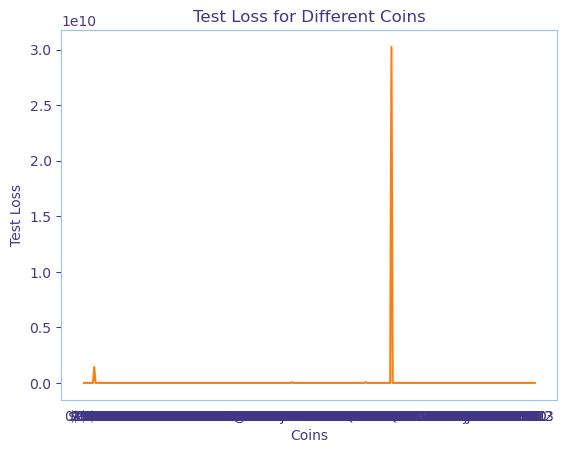

In [125]:
import matplotlib.pyplot as plt

def plot_template():
    fig, ax = plt.subplots()
    ax.spines['bottom'].set_color('#98c6ea')  # x-axis color
    ax.spines['top'].set_color('#98c6ea')
    ax.spines['left'].set_color('#98c6ea')    # y-axis color
    ax.spines['right'].set_color('#98c6ea')
    ax.grid(True, color='#98c6ea', linestyle='--', linewidth=0.5) 
    ax.tick_params(axis='x', colors='#443686')  # x-axis tick labels
    ax.tick_params(axis='y', colors="#443686")   # y-axis tick labels
    return ax

ax = plot_template()
ax.plot(df_test_results['symbol'], df_test_results['test_loss'], color='#ff7f0e', label='Test Loss') #marker='o', linestyle='-', 
# plt.plot(row_counts_per_day.keys()[:100], row_counts_per_day.values[:100], color='#98c6ea', label='Row Counts Per Day') #marker='o', linestyle='-', 


# Customize axis title colors
ax.set_xlabel('Coins', color='#443686')  # x-axis title color
ax.set_ylabel('Test Loss', color='#443686') # y-axis title color
ax.set_title('Test Loss for Different Coins', color='#443686')  # Plot title color
ax.grid(False) 
ax.tick_params(axis='x', colors='#443686', which='both', bottom=False)

# plt.plot()

plt.show()